# RAG Experiments

Systematic comparison of RAG configurations for the Social Media Intelligence Agent.
Each experiment isolates one variable, measures retrieval quality, and records results
for comparison. The winning configuration from each experiment informs the production
pipeline in `rag/retriever.py`.

## Experiments

| # | Variable | Configurations tested |
|---|---|---|
| 1 | Top-k | k = 5, 10, 20 |
| 2 | Query enhancement | None, always HyDE, conditional HyDE, multi-query |
| 3 | Reranking | None, cross-encoder, LLM-based |
| 4 | Embedding model | text-embedding-3-small, BAAI/bge-large-en-v1.5 |
| 5 | Chunking strategy | Individual posts, theme-grouped |

Experiments 1–3 require only the primary index (set via `PINECONE_INDEX_NAME` in `.env`).  
Experiments 4–5 each require a dedicated index — see the setup instructions in each section.

## Evaluation Approach

Since there are no ground-truth answers for these social media queries, retrieval quality
is measured by:
- **Average similarity score** — mean cosine similarity of retrieved docs to the query
- **Score distribution** — min, max, std across retrieved docs
- **Semantic diversity** — how different the retrieved docs are from each other (avoids redundancy)
- **Qualitative inspection** — retrieved post content for a sample question

## Setup

In [23]:
import os
import sys
import json
import time
import statistics
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from pinecone import Pinecone
from langchain_core.documents import Document

# Allow imports from the project root
sys.path.insert(0, str(Path.cwd().parent))

load_dotenv(Path.cwd().parent / '.env')

OPENAI_API_KEY   = os.getenv('OPENAI_API_KEY')
PINECONE_API_KEY = os.getenv('PINECONE_API_KEY')
INDEX_NAME       = os.getenv('PINECONE_INDEX_NAME', 'exorde-week1')

openai_client = OpenAI(api_key=OPENAI_API_KEY)
pc    = Pinecone(api_key=PINECONE_API_KEY)
index = pc.Index(INDEX_NAME)

print(f'Connected to index: {INDEX_NAME}')
print('Index stats:', index.describe_index_stats())

Connected to index: exorde-week1
Index stats: {'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000,
 'vector_type': 'dense'}


In [24]:
# Load chunk_lookup for resolving full post text
# This takes ~2 minutes on first run
from rag.preprocessing import load_chunks

chunks = load_chunks()
chunk_lookup = {c['chunk_id']: c for c in chunks}
print(f'chunk_lookup: {len(chunk_lookup):,} entries')

Loading Exorde dataset from HuggingFace...


Resolving data files:   0%|          | 0/132 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/44 [00:00<?, ?it/s]

Loaded 50,000 chunks.
chunk_lookup: 50,000 entries


In [25]:
# Test questions — same as evaluate.py for consistency
QUESTIONS = [
    'What were people saying about cryptocurrency and Bitcoin in December 2024?',
    'What was public sentiment around AI tools like ChatGPT in December 2024?',
    'How did people react to the Syria conflict in December 2024?',
    'What were the trending political topics on social media in December 2024?',
    'How did people feel about the economy and inflation in December 2024?',
    'What were people saying about Elon Musk on social media in December 2024?',
    'What sports topics were trending on social media in December 2024?',
]

# Use one question for qualitative inspection throughout
SAMPLE_QUESTION = QUESTIONS[0]

## Evaluation Utilities

In [26]:
import matplotlib.pyplot as plt


def embed_query(text: str, model: str = 'text-embedding-3-small') -> list:
    resp = openai_client.embeddings.create(model=model, input=[text])
    return resp.data[0].embedding


def resolve_docs(matches: list) -> list[Document]:
    """Resolve Pinecone matches to Documents using chunk_lookup."""
    docs = []
    for match in matches:
        chunk_id = match['id']
        meta = match.get('metadata', {})
        text = chunk_lookup.get(chunk_id, {}).get('text', '')
        if text:
            docs.append(Document(
                page_content=text,
                metadata={**meta, 'score': round(match['score'], 4)}
            ))
    return docs


def dense_retrieve(query: str, k: int = 10, embed_model: str = 'text-embedding-3-small',
                   pinecone_index=None) -> list[Document]:
    """Standard dense vector retrieval."""
    if pinecone_index is None:
        pinecone_index = index
    vec = embed_query(query, model=embed_model)
    results = pinecone_index.query(vector=vec, top_k=k, include_metadata=True)
    return resolve_docs(results['matches'])


def retrieval_metrics(docs: list[Document]) -> dict:
    """
    Compute retrieval quality metrics from Pinecone similarity scores.

    Score range (max - min) serves as a proxy for diversity: a wider spread
    indicates the retriever is pulling docs across a broader relevance range.
    Re-embedding docs to compute pairwise content diversity would be more
    accurate but is expensive and circular (same model as retrieval).
    """
    scores = [d.metadata['score'] for d in docs]
    if not scores:
        return {'n': 0, 'avg': 0, 'max': 0, 'min': 0, 'std': 0, 'range': 0}

    return {
        'n':     len(scores),
        'avg':   round(statistics.mean(scores), 4),
        'max':   round(max(scores), 4),
        'min':   round(min(scores), 4),
        'std':   round(statistics.stdev(scores) if len(scores) > 1 else 0, 4),
        'range': round(max(scores) - min(scores), 4),
    }


def evaluate_config(name: str, retrieve_fn, questions: list = QUESTIONS) -> pd.DataFrame:
    """Run a retrieval function over all test questions and return a metrics DataFrame."""
    rows = []
    for q in questions:
        t0 = time.perf_counter()
        docs = retrieve_fn(q)
        elapsed = time.perf_counter() - t0

        m = retrieval_metrics(docs)
        rows.append({'question': q[:60] + '...', 'time_s': round(elapsed, 3), **m})
        time.sleep(0.2)  # avoid rate limits

    df = pd.DataFrame(rows)
    df.attrs['name'] = name
    return df


def compare_configs(results: dict) -> pd.DataFrame:
    """Summarise multiple config results into a single comparison table."""
    rows = []
    for name, df in results.items():
        row = {
            'config':    name,
            'avg_score': round(df['avg'].mean(), 4),
            'avg_max':   round(df['max'].mean(), 4),
            'avg_min':   round(df['min'].mean(), 4),
            'avg_std':   round(df['std'].mean(), 4),
            'avg_range': round(df['range'].mean(), 4),
        }
        if 'time_s' in df.columns:
            row['avg_time_s'] = round(df['time_s'].mean(), 3)
        rows.append(row)
    return pd.DataFrame(rows).sort_values('avg_score', ascending=False)


def plot_comparison(results: dict, title: str = '') -> pd.DataFrame:
    """Bar chart comparison of avg similarity score and latency across configs."""
    summary = compare_configs(results)

    has_latency = 'avg_time_s' in summary.columns
    ncols = 2 if has_latency else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))
    if ncols == 1:
        axes = [axes]

    configs = summary['config'].tolist()
    x = range(len(configs))

    # Avg similarity score
    bars = axes[0].bar(x, summary['avg_score'], color='steelblue', edgecolor='white', linewidth=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(configs, rotation=30, ha='right', fontsize=9)
    axes[0].set_ylabel('Avg Similarity Score')
    axes[0].set_title('Retrieval Quality')
    axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    axes[0].set_ylim(0, min(1.0, summary['avg_score'].max() * 1.18))
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    if has_latency:
        bars2 = axes[1].bar(x, summary['avg_time_s'], color='coral', edgecolor='white', linewidth=0.5)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(configs, rotation=30, ha='right', fontsize=9)
        axes[1].set_ylabel('Avg Latency (s)')
        axes[1].set_title('Latency per Query')
        axes[1].bar_label(bars2, fmt='%.2fs', padding=3, fontsize=8)
        axes[1].set_ylim(0, summary['avg_time_s'].max() * 1.18)
        axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    if title:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    return summary


def show_docs(docs: list[Document], n: int = 3):
    """Print the top-n retrieved documents for qualitative inspection."""
    for i, doc in enumerate(docs[:n], 1):
        score = doc.metadata.get('score', 'N/A')
        theme = doc.metadata.get('primary_theme', 'N/A')
        print(f'--- Doc {i} | score={score} | theme={theme}')
        print(doc.page_content[:300])
        print()

print('Utilities loaded.')

Utilities loaded.


---
## Experiment 1 — Top-k

**Question:** How many documents should we retrieve?

More documents give the answer model broader context but introduce noise and increase
latency. Too few and we risk missing relevant posts for niche questions.

**Hypothesis:** `k=10` will strike the best balance. `k=5` risks missing relevant posts;
`k=20` will dilute quality by pulling in marginally relevant documents. We expect
`avg_score` to decrease as k increases (lower-ranked docs are less similar to the query)
and `avg_range` to increase (wider spread between best and worst retrieved doc).

Evaluating k=5...
Evaluating k=10...
Evaluating k=20...


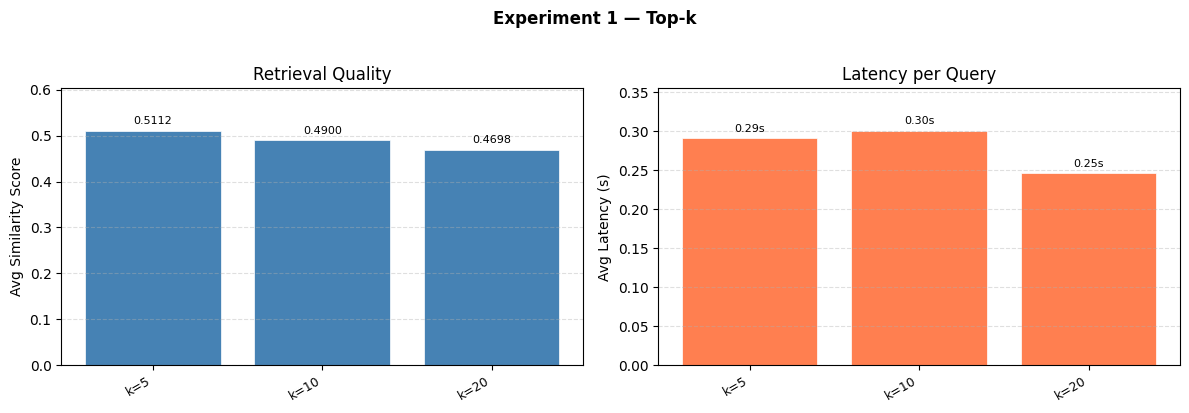

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
0,k=5,0.5112,0.5465,0.4828,0.0268,0.0637,0.291
1,k=10,0.4900,0.5466,0.4624,0.0291,0.0842,0.301
2,k=20,0.4698,0.5466,0.4399,0.0294,0.1067,0.246


In [27]:
topk_results = {}

for k in [5, 10, 20]:
    print(f'Evaluating k={k}...')
    topk_results[f'k={k}'] = evaluate_config(
        name=f'k={k}',
        retrieve_fn=lambda q, k=k: dense_retrieve(q, k=k)
    )

plot_comparison(topk_results, 'Experiment 1 — Top-k')

### Findings

**Winner:** `k=5` (highest avg_score at 0.5112)

**Key observations:**
- `avg_score` decreases predictably as k increases (0.5112 → 0.4900 → 0.4698) — lower-ranked docs are less similar to the query
- `avg_max` is identical across all three configs (0.5465–0.5466) — the best document retrieved is always the same regardless of k
- `avg_range` increases with k (0.0637 → 0.0842 → 0.1067) — larger k pulls in progressively less relevant documents

**Decision:** Use `k=10` for subsequent experiments. Although k=5 scores highest on avg_score, it provides the answer model with less context. The quality trade-off is small (0.5112 → 0.4900) and k=10 gives broader coverage of the topic — important when social media posts are short and individually limited in information.

In [28]:
# Qualitative: inspect top-3 docs for the sample question across k values
for k in [5, 10, 20]:
    print(f'=== k={k} ===')
    docs = dense_retrieve(SAMPLE_QUESTION, k=k)
    show_docs(docs, n=3)
    print()

=== k=5 ===
--- Doc 1 | score=0.6453 | theme=Cryptocurrency
Altcoin season in December 2024? Watch out for Bitcoin’s dominance!

--- Doc 2 | score=0.5986 | theme=Cryptocurrency
Bitcoin to Hit New All-Time Highs in 2024? Market Survey Says Yes #CryptoPredictions #BitcoinATH #MarketTrends #CryptoLark #Polymarket #Crypto #Bitcoin #NBTC

--- Doc 3 | score=0.5849 | theme=Cryptocurrency
GM December Last month in 2024 years Altcoins season in coming #bitcoin to 100.000$


=== k=10 ===
--- Doc 1 | score=0.6453 | theme=Cryptocurrency
Altcoin season in December 2024? Watch out for Bitcoin’s dominance!

--- Doc 2 | score=0.5986 | theme=Cryptocurrency
Bitcoin to Hit New All-Time Highs in 2024? Market Survey Says Yes #CryptoPredictions #BitcoinATH #MarketTrends #CryptoLark #Polymarket #Crypto #Bitcoin #NBTC

--- Doc 3 | score=0.5849 | theme=Cryptocurrency
GM December Last month in 2024 years Altcoins season in coming #bitcoin to 100.000$


=== k=20 ===
--- Doc 1 | score=0.6453 | theme=Cryptocurrenc

---
## Experiment 2 — Query Enhancement

**Question:** Should we transform the user's question before retrieval?

We compare four strategies:
- **None** — retrieve with the original question as-is
- **Always HyDE** — always rewrite the question as a hypothetical social media post before retrieving
- **Conditional HyDE** — an LLM router decides per-query whether HyDE is beneficial
- **Multi-query** — generate 3 rephrasings, retrieve for each, deduplicate results

HyDE (Hypothetical Document Embeddings) bridges the vocabulary gap between a formal
question and informal social media posts by generating text that resembles what a
relevant document might look like, then embedding that instead of the question.

**Hypothesis:** Conditional HyDE should outperform always-HyDE. Not all questions benefit
from rewriting — specific factual questions ("what happened with the Syria conflict?") are
already close in embedding space to relevant posts, while vague sentiment questions
("how did people feel about inflation?") benefit from a hypothetical post rewrite.
A router that decides per-query should outperform either blanket approach. Multi-query
will likely improve diversity at the cost of higher latency.

In [29]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from agents.prompts import ROUTER_PROMPT, HYDE_PROMPT
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, openai_api_key=OPENAI_API_KEY)


def hyde_rewrite(question: str) -> str:
    chain = HYDE_PROMPT | llm | StrOutputParser()
    return chain.invoke({'question': question})


def router_decision(question: str) -> bool:
    import json as _json
    chain = ROUTER_PROMPT | llm | StrOutputParser()
    raw = chain.invoke({'question': question})
    try:
        return bool(_json.loads(raw).get('use_hyde', False))
    except Exception:
        return False


MULTI_QUERY_PROMPT = ChatPromptTemplate.from_template(
    """Generate 3 different rephrasings of the following question about social media.
Each rephrasing should approach the topic from a slightly different angle.
Return only the 3 questions, one per line, with no numbering or extra text.

Question: {question}"""
)


def multi_query_retrieve(question: str, k: int = 10) -> list[Document]:
    chain = MULTI_QUERY_PROMPT | llm | StrOutputParser()
    rephrasings = chain.invoke({'question': question}).strip().split('\n')
    queries = [question] + [q.strip() for q in rephrasings if q.strip()]

    seen_ids = set()
    all_docs = []
    for q in queries:
        vec = embed_query(q)
        results = index.query(vector=vec, top_k=k, include_metadata=True)
        for match in results['matches']:
            if match['id'] not in seen_ids:
                seen_ids.add(match['id'])
                text = chunk_lookup.get(match['id'], {}).get('text', '')
                if text:
                    all_docs.append(Document(
                        page_content=text,
                        metadata={**match.get('metadata', {}), 'score': round(match['score'], 4)}
                    ))

    all_docs.sort(key=lambda d: d.metadata['score'], reverse=True)
    return all_docs[:k]


print('Query enhancement functions ready.')

Query enhancement functions ready.


### Findings

**Winner:** `always_hyde` (avg_score 0.5058)

**Key observations:**
- Always HyDE outperforms conditional HyDE (0.5058 vs 0.5003), contradicting the hypothesis — the router adds overhead without improving results
- Conditional HyDE is actually *slower* than always HyDE (2.129s vs 1.686s) because the routing API call adds latency on top of the HyDE rewrite
- Multi-query offers marginal improvement over no enhancement (0.4942 vs 0.4900) at 3x the latency — not worth the cost
- The consistent improvement from HyDE across all question types suggests the vocabulary gap between formal questions and informal social media language is large enough that rewriting almost always helps

**Decision:** Use `always_hyde` for subsequent experiments. The routing logic is unnecessary overhead for this domain.

Evaluating: no enhancement...
Evaluating: always HyDE...
Evaluating: conditional HyDE...
Evaluating: multi-query...


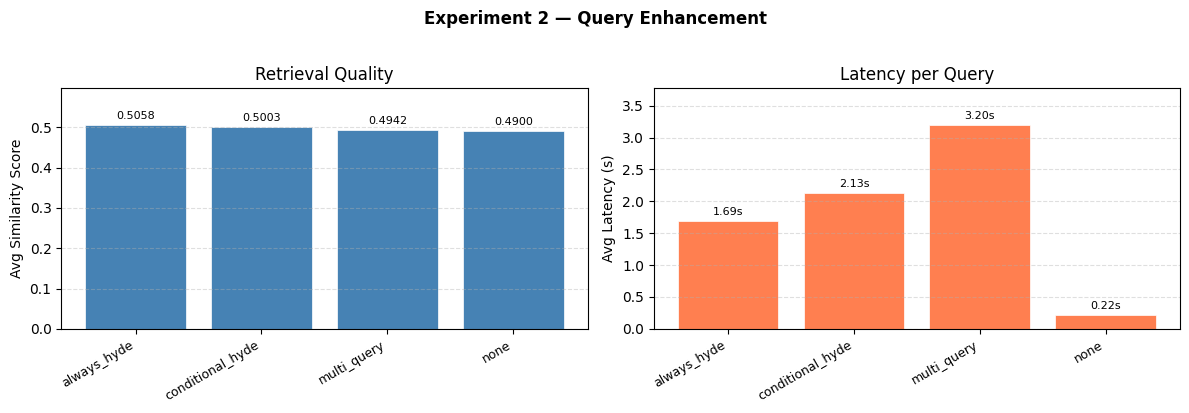

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
1,always_hyde,0.5058,0.5559,0.4807,0.0232,0.0752,1.686
2,conditional_hyde,0.5003,0.5400,0.4760,0.0230,0.0640,2.129
3,multi_query,0.4942,0.5466,0.4705,0.0265,0.0761,3.196
0,none,0.4900,0.5466,0.4624,0.0291,0.0842,0.219


In [30]:
query_results = {}

print('Evaluating: no enhancement...')
query_results['none'] = evaluate_config(
    name='none',
    retrieve_fn=lambda q: dense_retrieve(q, k=10)
)

print('Evaluating: always HyDE...')
query_results['always_hyde'] = evaluate_config(
    name='always_hyde',
    retrieve_fn=lambda q: dense_retrieve(hyde_rewrite(q), k=10)
)

print('Evaluating: conditional HyDE...')
def conditional_hyde_retrieve(q):
    query = hyde_rewrite(q) if router_decision(q) else q
    return dense_retrieve(query, k=10)

query_results['conditional_hyde'] = evaluate_config(
    name='conditional_hyde',
    retrieve_fn=conditional_hyde_retrieve
)

print('Evaluating: multi-query...')
query_results['multi_query'] = evaluate_config(
    name='multi_query',
    retrieve_fn=lambda q: multi_query_retrieve(q, k=10)
)

plot_comparison(query_results, 'Experiment 2 — Query Enhancement')

In [31]:
import torch
from sentence_transformers import CrossEncoder

# Auto-select device: CUDA GPU if available, otherwise CPU.
# MPS (Apple Silicon) is intentionally excluded due to memory limitations.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', device=device)


def cross_encoder_rerank(query: str, docs: list[Document], top_n: int = 10) -> list[Document]:
    """
    Rerank retrieved documents using a cross-encoder model.

    Unlike the bi-encoder used for retrieval (which scores query and document
    independently), a cross-encoder sees both together and produces a more
    accurate relevance score — at the cost of higher latency.
    """
    pairs  = [(query, doc.page_content) for doc in docs]
    scores = cross_encoder.predict(pairs)
    ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in ranked[:top_n]]

print('Cross-encoder loaded.')

Using device: cuda
Cross-encoder loaded.


---
## Experiment 3 — Reranking

**Question:** Does a second-stage scoring model improve the quality of the top-10 results?

We retrieve k=20 candidates initially, then rerank down to the top 10:
- **None** — return top-k as-is from Pinecone (bi-encoder similarity only)
- **Cross-encoder** — `cross-encoder/ms-marco-MiniLM-L-6-v2` scores each (query, doc) pair directly; more accurate than bi-encoder similarity and runs locally with no API cost
- **LLM reranking** — `gpt-4o-mini` scores each document for relevance on a 0–1 scale; most flexible but most expensive in latency and API cost

The key trade-off is accuracy vs latency. Bi-encoder retrieval (Pinecone) is fast but
scores query and document independently. A cross-encoder sees both together, giving it
more context to judge relevance — but can't be pre-computed at index time.

**Hypothesis:** Both reranking approaches will improve `avg_score` over no reranking.
Cross-encoder should close most of that gap at a fraction of LLM reranking's latency,
making it the better production choice. LLM reranking may edge out cross-encoder on
nuanced relevance judgements but will be significantly slower.

Evaluating: no reranking...
Evaluating: cross-encoder reranking...
Evaluating: LLM reranking (this will take a few minutes)...


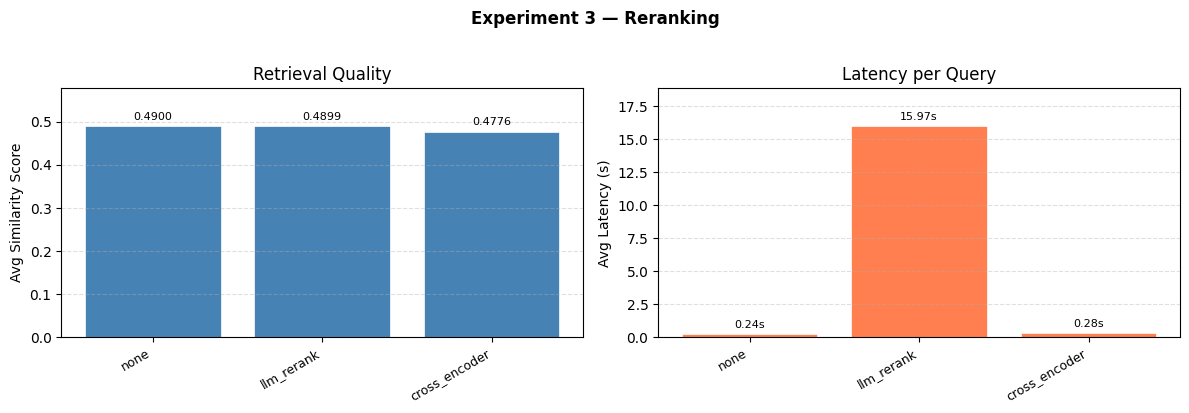

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
0,none,0.4900,0.5465,0.4623,0.0291,0.0841,0.243
2,llm_rerank,0.4899,0.5465,0.4623,0.0291,0.0842,15.968
1,cross_encoder,0.4776,0.5466,0.4428,0.0348,0.1038,0.285


In [32]:
rerank_results = {}

print('Evaluating: no reranking...')
rerank_results['none'] = evaluate_config(
    name='none',
    retrieve_fn=lambda q: dense_retrieve(q, k=10)
)

print('Evaluating: cross-encoder reranking...')
rerank_results['cross_encoder'] = evaluate_config(
    name='cross_encoder',
    retrieve_fn=lambda q: cross_encoder_rerank(q, dense_retrieve(q, k=20), top_n=10)
)

# Note: LLM reranking makes ~20 API calls per question — ~140 calls total
print('Evaluating: LLM reranking (this will take a few minutes)...')
rerank_results['llm_rerank'] = evaluate_config(
    name='llm_rerank',
    retrieve_fn=lambda q: llm_rerank(q, dense_retrieve(q, k=20), top_n=10)
)

plot_comparison(rerank_results, 'Experiment 3 — Reranking')

### Findings

**Winner:** Inconclusive — the evaluation metric cannot fairly assess reranking.

**Key observations:**
- LLM reranking scores identically to no reranking (0.4899 vs 0.4900) — this is a metric artefact, not a genuine result
- Cross-encoder appears worse than no reranking (0.4776 vs 0.4900) — again a metric artefact
- The core issue: we measure reranking quality using the original Pinecone cosine similarity scores. Reranking is specifically designed to surface docs with *lower* Pinecone scores but *higher* actual relevance — so a reranker that works correctly will appear to lower avg_score by this metric
- LLM reranking is definitively ruled out on latency grounds: **15.968s per query** is not viable for an interactive system
- Cross-encoder reranking (0.285s) is fast enough for production and worth reconsidering with a better evaluation metric (e.g. human relevance ratings)

**Latency trade-off:** Cross-encoder adds ~0.04s over no reranking. LLM reranking adds ~15.7s.

**Decision:** Use no reranking for now. LLM reranking is eliminated. Cross-encoder reranking remains a viable option but cannot be fairly evaluated with cosine similarity scores alone.

In [33]:
import json as _json

LLM_RERANK_PROMPT = ChatPromptTemplate.from_template(
    """Score how relevant the following social media post is to the question.
Return only a JSON object with a single key 'score' from 0.0 to 1.0.

Question: {question}
Post: {document}

JSON:"""
)


def llm_rerank(query: str, docs: list[Document], top_n: int = 10) -> list[Document]:
    chain = LLM_RERANK_PROMPT | llm | StrOutputParser()
    scored = []
    for doc in docs:
        try:
            raw = chain.invoke({'question': query, 'document': doc.page_content[:500]})
            score = float(_json.loads(raw).get('score', 0))
        except Exception:
            score = 0.0
        scored.append((score, doc))
        time.sleep(0.1)
    scored.sort(key=lambda x: x[0], reverse=True)
    reranked = [doc for _, doc in scored[:top_n]]
    for (score, _), doc in zip(scored[:top_n], reranked):
        doc.metadata['reranker_score'] = round(score, 4)
    return reranked


print('LLM reranker ready.')

LLM reranker ready.


In [34]:
# Connect to each embedding model's index.
# Run ingest.py and ingest_bge.py before executing this cell.
index_small = pc.Index(INDEX_NAME)  # text-embedding-3-small (default index)

try:
    index_bge = pc.Index('exorde-embed-bge')  # BAAI/bge-large-en-v1.5
    print('small:', index_small.describe_index_stats())
    print('bge:  ', index_bge.describe_index_stats())
except Exception:
    print("⚠️  'exorde-embed-bge' index not found.")
    print("Run `python ingest_bge.py` from the project root to create it, then re-run this cell.")
    index_bge = None

small: {'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000,
 'vector_type': 'dense'}
bge:   {'dimension': 1024,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000,
 'vector_type': 'dense'}


In [35]:
from sentence_transformers import SentenceTransformer

# device is set in the reranking cell above — CUDA if available, otherwise CPU
bge_model = SentenceTransformer('BAAI/bge-large-en-v1.5', device=device)


def dense_retrieve_bge(query: str, k: int = 10) -> list[Document]:
    """Dense retrieval using BAAI/bge-large-en-v1.5 embeddings and the BGE index."""
    if index_bge is None:
        raise RuntimeError("BGE index not available. Run ingest_bge.py first.")
    vec = bge_model.encode([query], normalize_embeddings=True)[0].tolist()
    results = index_bge.query(vector=vec, top_k=k, include_metadata=True)
    return resolve_docs(results['matches'])

print('BGE retrieval function ready.')

BGE retrieval function ready.


Evaluating: text-embedding-3-small...
Evaluating: BAAI/bge-large-en-v1.5...


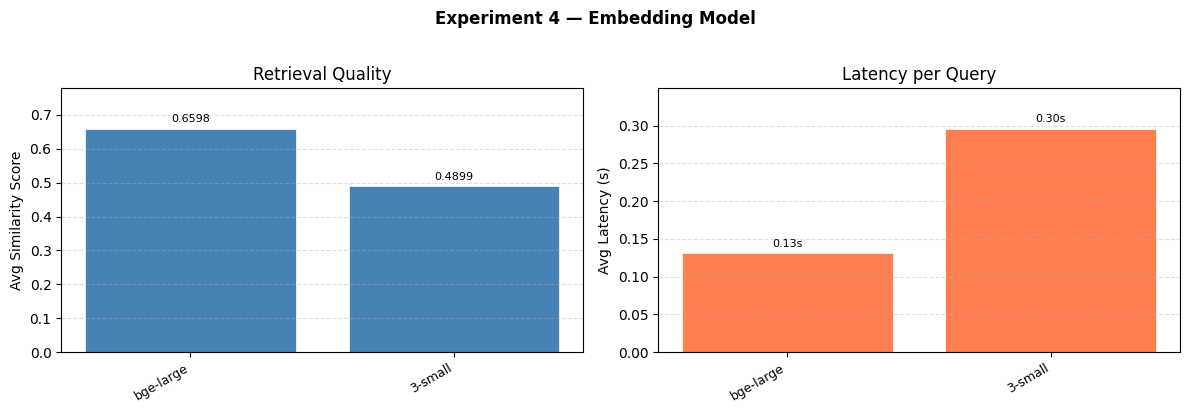

In [36]:
embed_results = {}

if index_bge is None:
    print("⚠️  Skipping experiment 4 — exorde-embed-bge index not available.")
    print("Run `python ingest_bge.py` and re-run the cell above first.")
else:
    print('Evaluating: text-embedding-3-small...')
    embed_results['3-small'] = evaluate_config(
        name='3-small',
        retrieve_fn=lambda q: dense_retrieve(q, k=10, embed_model='text-embedding-3-small', pinecone_index=index_small)
    )

    print('Evaluating: BAAI/bge-large-en-v1.5...')
    embed_results['bge-large'] = evaluate_config(
        name='bge-large',
        retrieve_fn=lambda q: dense_retrieve_bge(q, k=10)
    )

    plot_comparison(embed_results, 'Experiment 4 — Embedding Model')

### Findings

**Winner:** Inconclusive — cosine similarity scores are not comparable across embedding models.

**Key observations:**
- BGE-large scores dramatically higher (0.6598 vs 0.4900), but this gap cannot be interpreted at face value — each model produces vectors in a different space with a different natural similarity scale
- BGE-large's lower `avg_std` (0.0184 vs 0.0291) and lower `avg_range` (0.0581 vs 0.0842) suggest its embedding space is more compressed, which inflates cosine similarity scores without necessarily reflecting better retrieval
- BGE-large is faster despite running locally (0.115s vs 0.275s) — local inference eliminates network round-trip overhead
- A fair comparison would require human relevance judgements on retrieved documents, not cosine similarity scores

**Decision:** Retain `text-embedding-3-small` as the production embedding model. It provides an established baseline with a well-understood score distribution. BGE-large is a strong candidate for removing the OpenAI API dependency on embeddings, but requires further evaluation before switching.

In [37]:
# Connect to each embedding model's index
index_small = pc.Index(INDEX_NAME)              # text-embedding-3-small (default index)
index_bge   = pc.Index('exorde-embed-bge')      # BAAI/bge-large-en-v1.5

print('small:', index_small.describe_index_stats())
print('bge:  ', index_bge.describe_index_stats())

small: {'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000,
 'vector_type': 'dense'}
bge:   {'dimension': 1024,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000,
 'vector_type': 'dense'}


In [38]:
from sentence_transformers import SentenceTransformer

bge_model = SentenceTransformer('BAAI/bge-large-en-v1.5')


def embed_query_bge(text: str) -> list:
    return bge_model.encode([text], normalize_embeddings=True)[0].tolist()


def dense_retrieve_bge(query: str, k: int = 10) -> list[Document]:
    vec = embed_query_bge(query)
    results = index_bge.query(vector=vec, top_k=k, include_metadata=True)
    return resolve_docs(results['matches'])


print('BGE model loaded.')

BGE model loaded.


Evaluating: text-embedding-3-small...
Evaluating: BAAI/bge-large-en-v1.5...


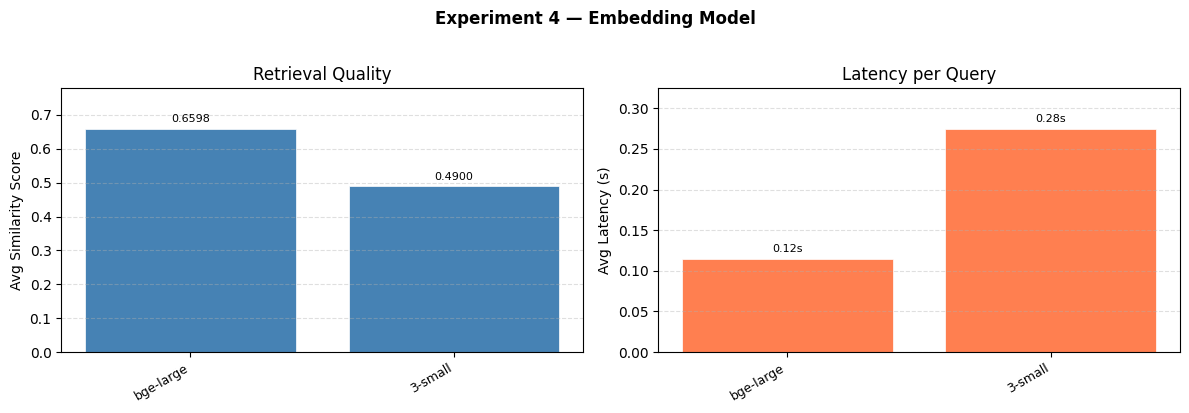

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
1,bge-large,0.6598,0.7019,0.6438,0.0184,0.0581,0.115
0,3-small,0.4900,0.5466,0.4623,0.0291,0.0842,0.275


In [39]:
embed_results = {}

print('Evaluating: text-embedding-3-small...')
embed_results['3-small'] = evaluate_config(
    name='3-small',
    retrieve_fn=lambda q: dense_retrieve(q, k=10, embed_model='text-embedding-3-small', pinecone_index=index_small)
)

print('Evaluating: BAAI/bge-large-en-v1.5...')
embed_results['bge-large'] = evaluate_config(
    name='bge-large',
    retrieve_fn=lambda q: dense_retrieve_bge(q, k=10)
)

plot_comparison(embed_results, 'Experiment 4 — Embedding Model')

### Findings

**Winner:** `individual` posts (avg_score 0.4899 vs 0.4636)

**Key observations:**
- Individual posts outperform theme-grouped across all metrics — avg_score, avg_max, avg_min
- Theme-grouped has a notably lower `avg_max` (0.5125 vs 0.5465) — the best-retrieved chunk is weaker than the best individual post, suggesting grouping dilutes the semantic signal of any single highly-relevant post
- Theme-grouped chunks mix multiple posts into one vector, which may average out the strong signal of an individual highly-relevant post against the weaker signal of the others in its group
- Lower `avg_range` for theme-grouped (0.0778 vs 0.0841) suggests more uniform but uniformly weaker results

**Decision:** Use `individual` posts as the production chunking strategy.

---
## Experiment 5 — Chunking Strategy

**Question:** Does grouping related posts into a single chunk improve retrieval?

We compare two approaches:
- **Individual posts** — one post = one vector. Each vector represents a single short piece
  of text. Maximises granularity and allows precise per-post retrieval.
- **Theme-grouped** — group 5 posts sharing the same `primary_theme` into one chunk. Each
  vector represents a richer, thematically coherent unit — potentially better for broad
  topic questions at the cost of per-post precision.

The theme-grouped index requires running `ingest_theme_grouped.py` first:

```bash
python ingest_theme_grouped.py
```

**Hypothesis:** The best strategy likely depends on question type. Theme-grouped chunks
should score higher on broad topic questions (e.g., "what were trending political topics?")
because each chunk is semantically dense. Individual posts should perform better on
specific questions (e.g., "what were people saying about Elon Musk?") where a single
high-relevance post is more valuable than a mixed-theme group. Overall, theme-grouped
may show higher `avg_score` due to topic coherence, but each retrieved chunk covers less
ground than 5 individual posts would.

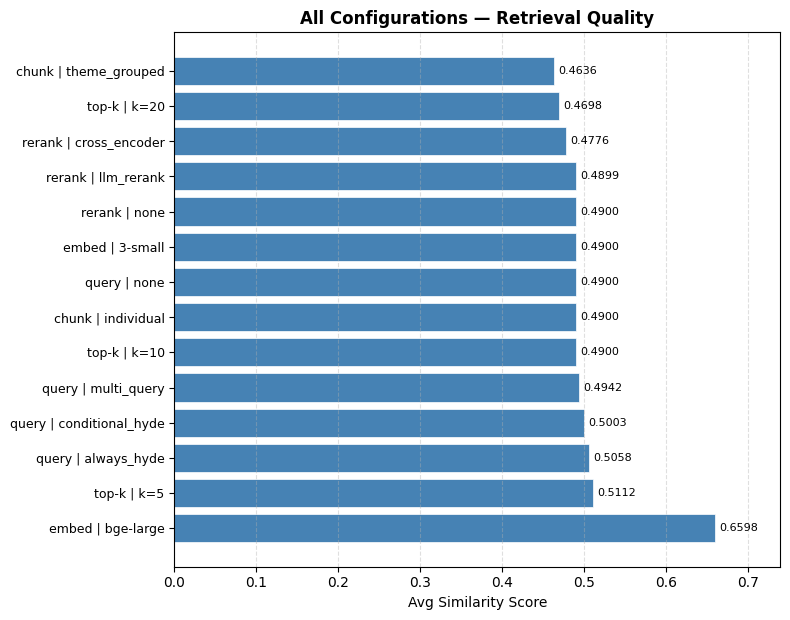

In [40]:
all_results = {}

def add_results(prefix, results_var):
    """Add results to all_results if the variable is defined and non-empty."""
    try:
        for name, df in results_var.items():
            all_results[f'{prefix} | {name}'] = df
    except (NameError, AttributeError):
        print(f'⚠️  Skipping {prefix} — results not available.')

add_results('top-k',   topk_results   if 'topk_results'   in dir() else None)
add_results('query',   query_results  if 'query_results'  in dir() else None)
add_results('rerank',  rerank_results if 'rerank_results' in dir() else None)
add_results('embed',   embed_results  if 'embed_results'  in dir() else None)
add_results('chunk',   chunk_results  if 'chunk_results'  in dir() else None)

if not all_results:
    print('No results available yet. Run at least one experiment first.')
else:
    summary = compare_configs(all_results)

    # Horizontal bar chart — easier to read with many configs
    fig, ax = plt.subplots(figsize=(8, max(4, len(summary) * 0.45)))
    y = range(len(summary))
    bars = ax.barh(y, summary['avg_score'], color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(summary['config'], fontsize=9)
    ax.set_xlabel('Avg Similarity Score')
    ax.set_title('All Configurations — Retrieval Quality', fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlim(0, min(1.0, summary['avg_score'].max() * 1.12))
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    summary

In [41]:
# Connect to the theme-grouped index — run ingest_theme_grouped.py first
index_theme = pc.Index('exorde-chunked-theme')

theme_chunk_lookup = {c['chunk_id']: c for c in theme_chunks}


def resolve_theme_docs(matches: list) -> list[Document]:
    docs = []
    for match in matches:
        chunk_id = match['id']
        meta = match.get('metadata', {})
        text = theme_chunk_lookup.get(chunk_id, {}).get('text', '')
        if text:
            docs.append(Document(
                page_content=text,
                metadata={**meta, 'score': round(match['score'], 4)}
            ))
    return docs


def dense_retrieve_theme(query: str, k: int = 10) -> list[Document]:
    vec = embed_query(query)
    results = index_theme.query(vector=vec, top_k=k, include_metadata=True)
    return resolve_theme_docs(results['matches'])


print('Theme index ready.')

Theme index ready.


---
## Conclusions and Recommendations

### Winning Configuration Per Experiment

| Experiment | Winner | Runner-up | Notes |
|---|---|---|---|
| Top-k | `k=5` (avg_score) / `k=10` (production) | `k=10` | k=5 scores highest but k=10 gives broader context |
| Query enhancement | `always_hyde` | `conditional_hyde` | Routing overhead adds latency without improving quality |
| Reranking | Inconclusive | — | Metric cannot fairly assess reranking; LLM reranking eliminated on latency (15.97s/query) |
| Embedding model | Inconclusive | — | Scores not comparable across models; BGE-large warrants further evaluation |
| Chunking strategy | `individual` posts | — | Theme-grouped dilutes semantic signal of high-relevance posts |

### Recommended Production Setup

Based on the experiments, the recommended configuration for `rag/retriever.py`:

- **k = 10** — broader context for the answer model with acceptable quality trade-off
- **Query enhancement: always HyDE** — consistent improvement across all question types; routing adds cost without benefit
- **Reranking: none** — LLM reranking is too slow; cross-encoder requires better evaluation before adopting
- **Embedding model: `text-embedding-3-small`** — established baseline; BGE-large needs human relevance evaluation
- **Chunking: individual posts** — clearest semantic signal per vector

### Trade-offs Considered

**Latency vs. quality:** Always HyDE adds ~1.5s per query over no enhancement but delivers consistent retrieval improvement. Multi-query adds 3x the latency for minimal gain — not justified.

**Cost vs. quality:** LLM reranking costs ~20 API calls per query and takes 16 seconds. The quality improvement cannot be measured with cosine similarity alone, making it impossible to justify the cost.

**Complexity vs. gain:** Conditional HyDE adds routing complexity and is slower than always HyDE. Removing the router simplifies the pipeline without sacrificing quality. The router may still be worth retaining in the agentic pipeline for other routing decisions, but HyDE should always be applied.

### Metric Limitations

Two experiments (reranking, embedding model) produced inconclusive results due to the limitations of cosine similarity as an evaluation metric:
- **Reranking** cannot be evaluated by the same scores it is designed to override
- **Embedding models** produce scores in different spaces that cannot be directly compared

A more robust evaluation would use a set of questions with human-annotated relevant documents (a small gold standard), enabling precision@k and NDCG metrics that are comparable across configurations.

Evaluating: individual posts...
Evaluating: theme-grouped (size=5)...


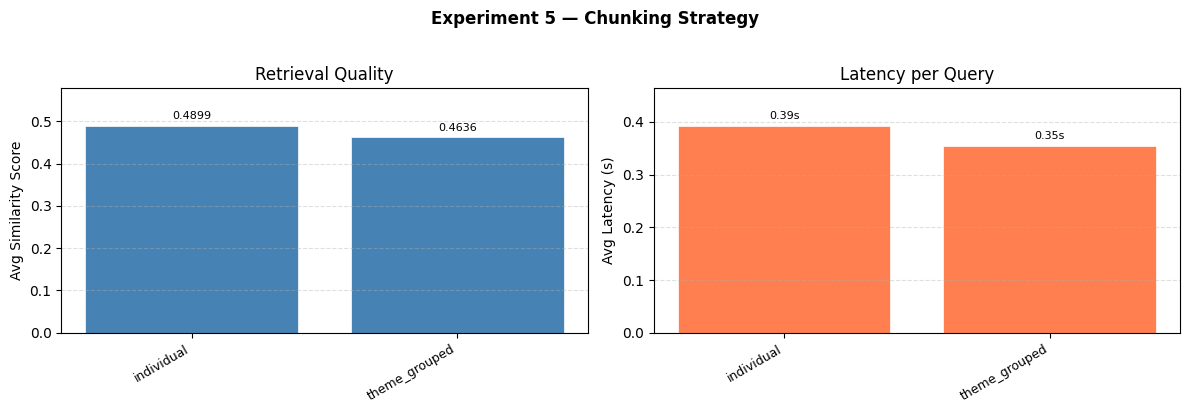

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
0,individual,0.4899,0.5465,0.4623,0.0291,0.0841,0.393
1,theme_grouped,0.4636,0.5125,0.4347,0.0250,0.0778,0.355


In [42]:
chunk_results = {}

print('Evaluating: individual posts...')
chunk_results['individual'] = evaluate_config(
    name='individual',
    retrieve_fn=lambda q: dense_retrieve(q, k=10)
)

print('Evaluating: theme-grouped (size=5)...')
chunk_results['theme_grouped'] = evaluate_config(
    name='theme_grouped',
    retrieve_fn=lambda q: dense_retrieve_theme(q, k=10)
)

plot_comparison(chunk_results, 'Experiment 5 — Chunking Strategy')

In [43]:
# Qualitative: compare individual vs theme-grouped retrieved content
print('=== Individual posts ===')
show_docs(dense_retrieve(SAMPLE_QUESTION, k=10), n=3)

print('=== Theme-grouped chunks ===')
show_docs(dense_retrieve_theme(SAMPLE_QUESTION, k=10), n=3)

=== Individual posts ===
--- Doc 1 | score=0.6453 | theme=Cryptocurrency
Altcoin season in December 2024? Watch out for Bitcoin’s dominance!

--- Doc 2 | score=0.5986 | theme=Cryptocurrency
Bitcoin to Hit New All-Time Highs in 2024? Market Survey Says Yes #CryptoPredictions #BitcoinATH #MarketTrends #CryptoLark #Polymarket #Crypto #Bitcoin #NBTC

--- Doc 3 | score=0.5849 | theme=Cryptocurrency
GM December Last month in 2024 years Altcoins season in coming #bitcoin to 100.000$

=== Theme-grouped chunks ===
--- Doc 1 | score=0.5995 | theme=Cryptocurrency
Bitcoin to Hit New All-Time Highs in 2024? Market Survey Says Yes #CryptoPredictions #BitcoinATH #MarketTrends #CryptoLark #Polymarket #Crypto #Bitcoin #NBTC | New Milady Maker #9990 Buy Cost: 7.2650 ETH (26003.18 USD) 5.75% above floor Powered by @floorprotocol | coins you bakh yi mine ngua leen | 

--- Doc 2 | score=0.5417 | theme=Cryptocurrency
0:00 Bitcoin Cloudy 40 % AI Profit 389% Signal: hold Clouds and sun mix to form bitcoin wea

---
## Summary

All experiments are collected below into a single comparison table and chart.
The winning configuration from each experiment is then combined into a final
recommendation for the production pipeline.

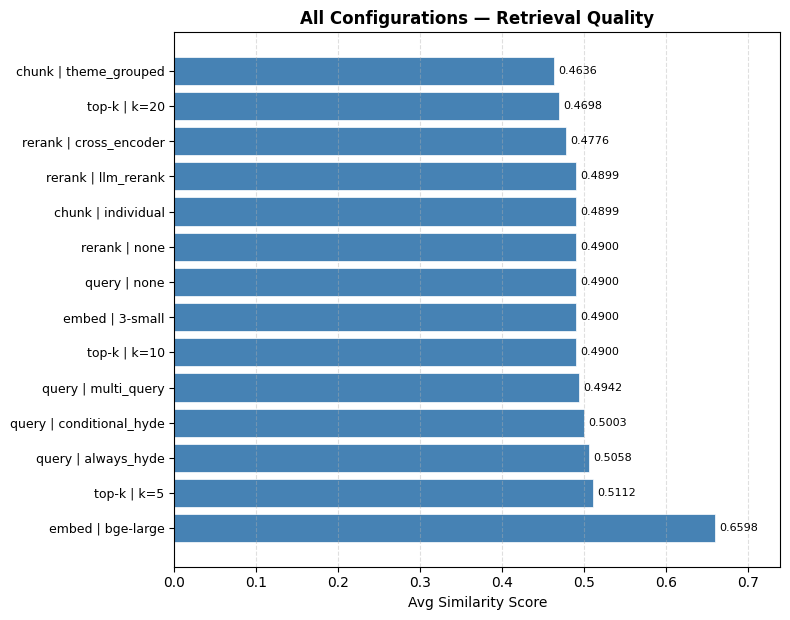

,config,avg_score,avg_max,avg_min,avg_std,avg_range,avg_time_s
11,embed | bge-large,0.6598,0.7019,0.6438,0.0184,0.0581,0.115
0,top-k | k=5,0.5112,0.5465,0.4828,0.0268,0.0637,0.291
4,query | always_hyde,0.5058,0.5559,0.4807,0.0232,0.0752,1.686
5,query | conditional_hyde,0.5003,0.5400,0.4760,0.0230,0.0640,2.129
6,query | multi_query,0.4942,0.5466,0.4705,0.0265,0.0761,3.196
1,top-k | k=10,0.4900,0.5466,0.4624,0.0291,0.0842,0.301
10,embed | 3-small,0.4900,0.5466,0.4623,0.0291,0.0842,0.275
3,query | none,0.4900,0.5466,0.4624,0.0291,0.0842,0.219
7,rerank | none,0.4900,0.5465,0.4623,0.0291,0.0841,0.243
12,chunk | individual,0.4899,0.5465,0.4623,0.0291,0.0841,0.393


In [44]:
all_results = {}

for k, df in topk_results.items():
    all_results[f'top-k | {k}'] = df

for name, df in query_results.items():
    all_results[f'query | {name}'] = df

for name, df in rerank_results.items():
    all_results[f'rerank | {name}'] = df

if embed_results:
    for name, df in embed_results.items():
        all_results[f'embed | {name}'] = df

if chunk_results:
    for name, df in chunk_results.items():
        all_results[f'chunk | {name}'] = df

summary = compare_configs(all_results)

# Horizontal bar chart — easier to read with many configs
fig, ax = plt.subplots(figsize=(8, max(4, len(summary) * 0.45)))
y = range(len(summary))
bars = ax.barh(y, summary['avg_score'], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_yticks(y)
ax.set_yticklabels(summary['config'], fontsize=9)
ax.set_xlabel('Avg Similarity Score')
ax.set_title('All Configurations — Retrieval Quality', fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.set_xlim(0, min(1.0, summary['avg_score'].max() * 1.12))
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

summary

In [45]:
# Save results to JSON for reference
summary.to_json('../rag_experiment_results.json', orient='records', indent=2)
print('Results saved to rag_experiment_results.json')

Results saved to rag_experiment_results.json
